# Praktikum 12: RK Verfahren für Systeme von gDgl

In [118]:
import numpy as np
import matplotlib.pyplot as plt

generell: <br>
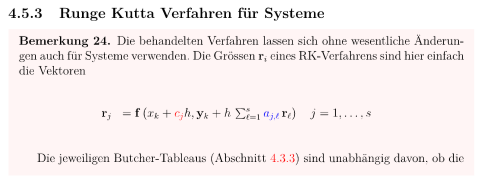

Explizit Euler, Explizit Trapezmethode (Heun):<br>
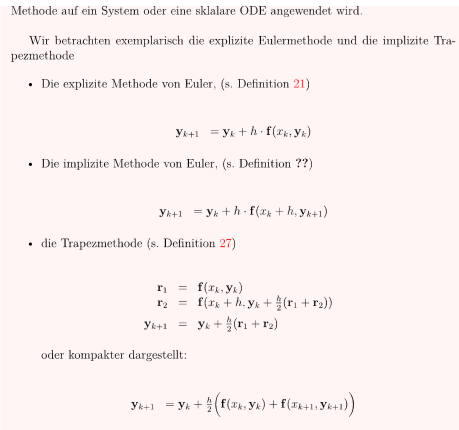

Heun Dummy code aus Skript:<br>
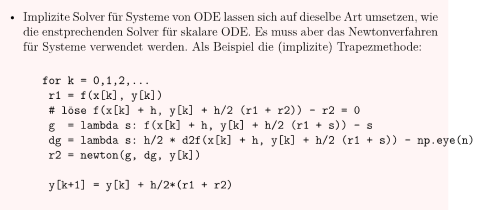



#RK4 für Systeme<br>
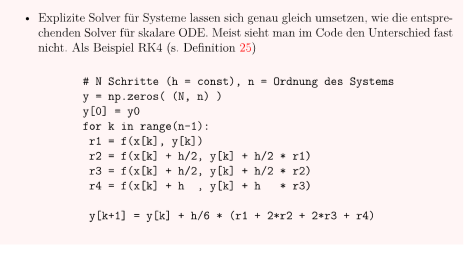

# Newtonverfahren für Systeme

In [119]:
# %% Newtonverfahren für Systeme
def newtonSystems(g, dg, r, tol = 1e-10, maxStep = 100):
    step = 0
    res = np.linalg.norm(g(r))
    while res > tol and step < maxStep:
        delta = np.linalg.solve(dg(r), g(r)) #...
        r -= delta        
        res = np.linalg.norm(g(r))        
        step += 1        
    assert(step < maxStep)        
    return r

# Implztite Mittelpunktsregel für Systeme

In [120]:

# implizite Mittelpunktsregel
def Mittelpunktsregel_Impl_Systems(f, d2f, x0, y0, xn, h):
    dim = len(y0)
    x = [x0]
    y = [y0]
    r = f(x0, y0) # erster Startwert
    while x[-1] < xn - h / 2:
        # r1 = f(x+h/2, y+h/2*r1)
        g  = lambda r: f(x[-1] + h/2, y[-1] + h/2 * r) - r
        dg = lambda r: h/2 * d2f(x[-1] + h/2, y[-1] + h/2 * r) - np.eye(dim)
        r = newtonSystems(g, dg, r)
        y.append(y[-1] + h * r)
        x.append(x[-1] + h)
        
    return np.array(x), np.array(y)

# Explizites + Implizites Eulerverfahren

In [121]:
# explizites Eulerverfahren
def eulerExplizit_Systems(f, x0, y0, xn, h):
    x = [x0]
    y = [y0]
    while x[-1] < xn - h / 2:
        y.append(y[-1] + h * f(x[-1], y[-1]))
        x.append(x[-1] + h)
    return np.array(x), np.array(y)

# implizites Eulerverfahren
def eulerImplizit_Systems(f, d2f, x0, y0, xn, h):
    dim = len(y0)
    x = [x0]
    y = [y0]
    while x[-1] < xn - h / 2:
        g  = lambda s: y[-1] + h * f(x[-1], s) - s
        dg = lambda s: h * d2f(x[-1], s) - np.eye(dim)
        r = y[-1].copy()
        s = newtonSystems(g, dg, r)
        y.append(s)
        x.append(x[-1] + h)
        
    return np.array(x), np.array(y)

# RK4 (mit Schrittweitensteuerung)

In [122]:
# Ein Schritt mit RK 4
def RK4step_Systems(x, y, f, h):
    r1 = f(x, y)
    r2 = f(x + h/2, y + h/2 * r1)
    r3 = f(x + h/2, y + h/2 * r2)
    r4 = f(x + h,   y + h   * r3)

    return y + h/6 * (r1 + 2 * r2 + 2 * r3 + r4)
    
def RK4_Schrittweitensteuerung_Systems(f, x0, y0, xn, tol = 1e-5):
    p = 4  # Fehlerordnung für RK 4
    h = (xn - x0) / 100 # Startwert für h
    rho = 0.9 # Sicherheitsfaktor
    
    x = [x0]
    y = [y0]

    while (x[-1] < xn - 1e-10):

        
        y1 = RK4step_Systems(x[-1], y[-1], f, h)
    
        y12 = RK4step_Systems(x[-1],       y[-1], f, h / 2)
        y22 = RK4step_Systems(x[-1] + h/2, y12,   f, h / 2)
    
        eta = 10 * np.linalg.norm(y1 - y22) / (1 - 2**(-p)) # zusätzlicher Sicherheitsfaktor in der Fehlerschätzung...

        if (eta < tol):
            x.append(x[-1] + h)
            y.append(y22) # wir nehmen den besseren Wert...
            
        h *= rho * (tol / (eta + 1e-5*tol))**(1/(p+1)) # Schrittweite wird in jedem Fall angepasst
        h = min(h, xn - x[-1]) # damit sollten wir die Endstelle nicht überschreiten

    return np.array(x), np.array(y)

Angewendet auf Federdämpfersystem:

Darstellung :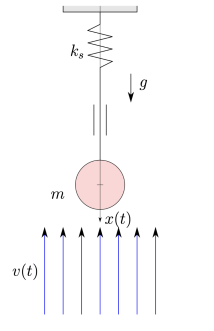<br>

Parameter: 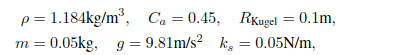 <br>

Gleichungen: 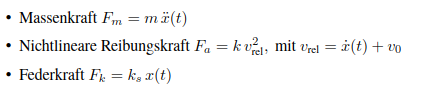 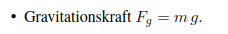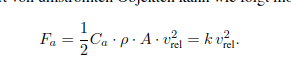<br>


In [123]:
##Parameter
p = 1.184 #kg/m3
Ca = 0.45
RKugel = 0.1 #m
m = 0.05 #kg
g = 9.81 #m/s2
ks = 0.05 #n/m FEDERKOONSTANTE
v0 = 0


#Modifizierbare Paramter

vLuft = 2 #EINSTELLBAR!
h = 0.8  # Schrittweite einstellbar. 0.8 für aufgabe 3
t_start = 0 # sekunden ?
t_end = 20 #sekunden?



#Berechnungen
Fg = m * g
AKugel = np.pi * RKugel**2  ## Kugel
k = 0.5 * Ca * p * AKugel  #  Luftwiderstandsfaktor 



# Anfangswerte definieren, x und v sind 0
y0 = np.array([0.0, 0.0])



# --- Definition des Systems ---
# Hilfe von chatgpt

def FederSystem(t, y):
    """
    Das System 1. Ordnung für die numerischen Verfahren.
    y[0] = x (Ort)
    y[1] = v (Geschwindigkeit)
    """

    # y[0] ist Ort x, y[1] ist Geschwindigkeit v
    x = y[0] 
    v = y[1]

    dx1 = v # Ort Abgeleitet ist geschwindigkeit---------einmal abgeleitetet


    v_rel = v + v0

    # hilfe chatgpt
    dx2 = g - (ks/m) * x - (k/m) * np.sign(v_rel) * v_rel**2 # Ort zweimal Abgeleitet ist Beschleunigung---------zweimal abgeleitetet

    dy1= dx1
    dy2 = dx2
    return np.array([dy1, dy2])


def Jaccobi_FederSystem(t, y):
    # y[0] = x, y[1] = v
    v_rel = y[1] + v0
    
    # Zeile 1
    df1_dy1 = 0
    df1_dy2 = 1
    
    # Zeile 2
    df2_dy1 = -ks / m
    df2_dy2 = -(k / m) * 2 * np.abs(v_rel)
    
    return np.array([[df1_dy1, df1_dy2], 
                     [df2_dy1, df2_dy2]])



# Untersuchen von unterschiedlichen Startgeschwindigkeiten mit RK4

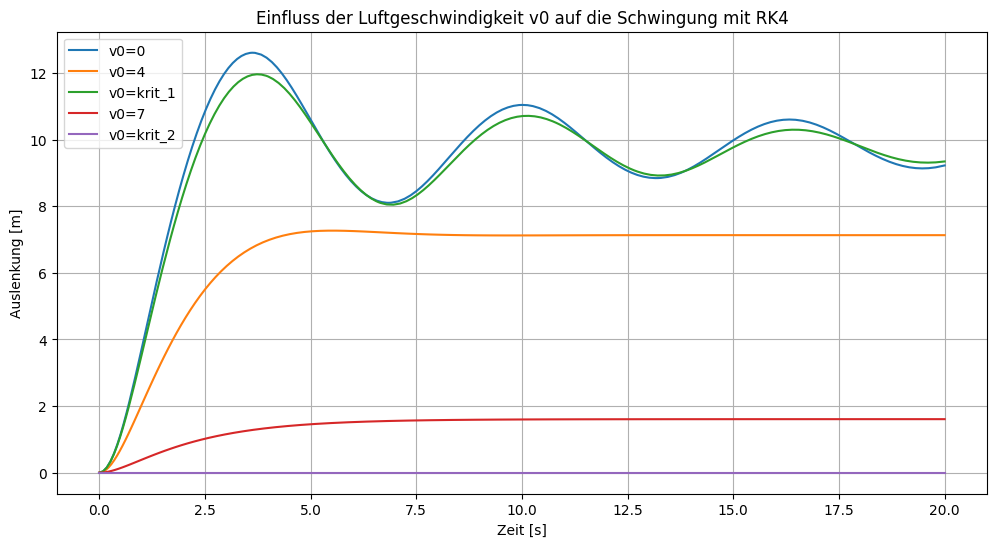

In [124]:
# Liste der zu untersuchenden Geschwindigkeiten
v0_werte = [0, 4, np.sqrt(ks*m/k), 7, np.sqrt(m*g/k)]
labels = ["v0=0", "v0=4", "v0=krit_1", "v0=7", "v0=krit_2"]
h = 0.25 # für diese aufgaben

plt.figure(figsize=(12, 6))

for i, v_test in enumerate(v0_werte):
    # v0 global für die Funktion FederSystem anpassen
    v0 = v_test 
    
    # Simulation starten (z.B. mit RK4)
    t, y = RK4_Schrittweitensteuerung_Systems(FederSystem, t_start, y0, t_end)
    
    # Plotten der Position x(t)
    plt.plot(t, y[:, 0], label=labels[i])

plt.title("Einfluss der Luftgeschwindigkeit v0 auf die Schwingung mit RK4")
plt.xlabel("Zeit [s]")
plt.ylabel("Auslenkung [m]")
plt.legend()
plt.grid(True)
plt.show()

# Untersuchen von unterschiedlichen Startgeschwindigkeiten mit Mittelpunktsregel

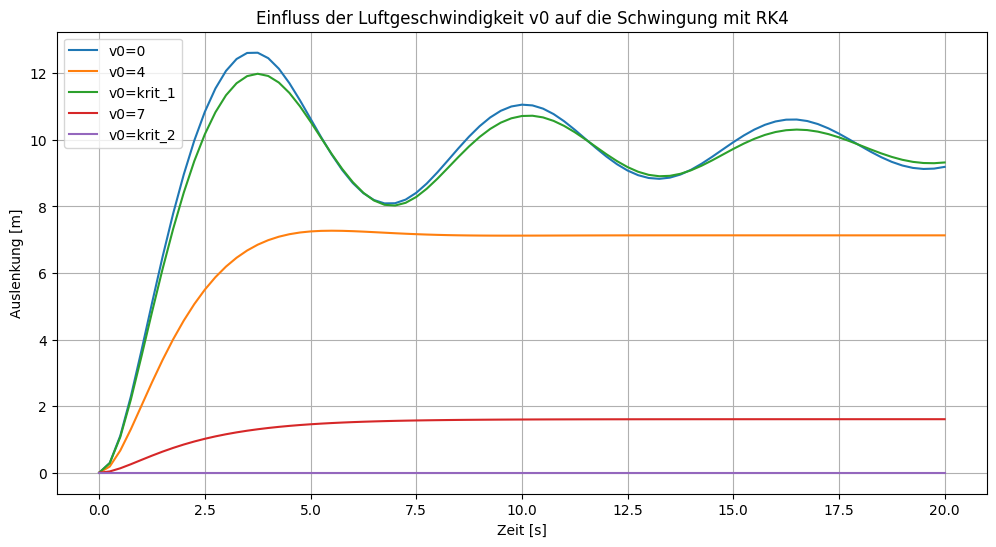

In [125]:
# Liste der zu untersuchenden Geschwindigkeiten
v0_werte = [0, 4, np.sqrt(ks*m/k), 7, np.sqrt(m*g/k)]
labels = ["v0=0", "v0=4", "v0=krit_1", "v0=7", "v0=krit_2"]
h = 0.25 # für diese aufgaben

plt.figure(figsize=(12, 6))

for i, v_test in enumerate(v0_werte):
    # v0 global für die Funktion FederSystem anpassen
    v0 = v_test 
    
    # Simulation starten (z.B. mit RK4)
    t, y = Mittelpunktsregel_Impl_Systems(FederSystem, Jaccobi_FederSystem, t_start, y0, t_end, h)
    
    # Plotten der Position x(t)
    plt.plot(t, y[:, 0], label=labels[i])

plt.title("Einfluss der Luftgeschwindigkeit v0 auf die Schwingung mit RK4")
plt.xlabel("Zeit [s]")
plt.ylabel("Auslenkung [m]")
plt.legend()
plt.grid(True)
plt.show()

# Vergleich RK4 und Mittelpunkt für Systeme

In [126]:
h= 0.8 # für diese aufgabe
v0 = 0 # für diese aufgabe


## CALLS
# y_ergebnisse enthält jetzt zwei Spalten:
# Spalte 0: Ort x(t)
# Spalte 1: Geschwindigkeit v(t)
t_MP_I, MP_I_y_ergebnisse = Mittelpunktsregel_Impl_Systems(FederSystem, Jaccobi_FederSystem, t_start, y0, t_end, h)
ort_MP_I = MP_I_y_ergebnisse[:, 0]
geschwindigkeit = MP_I_y_ergebnisse[:, 1]


t_RK4, RK4_y_ergebnisse = RK4_Schrittweitensteuerung_Systems(FederSystem, t_start, y0, t_end, tol=1e-5)
ort_RK4 = RK4_y_ergebnisse[:, 0]
geschwindigkeit = RK4_y_ergebnisse[:, 1]

#Plot



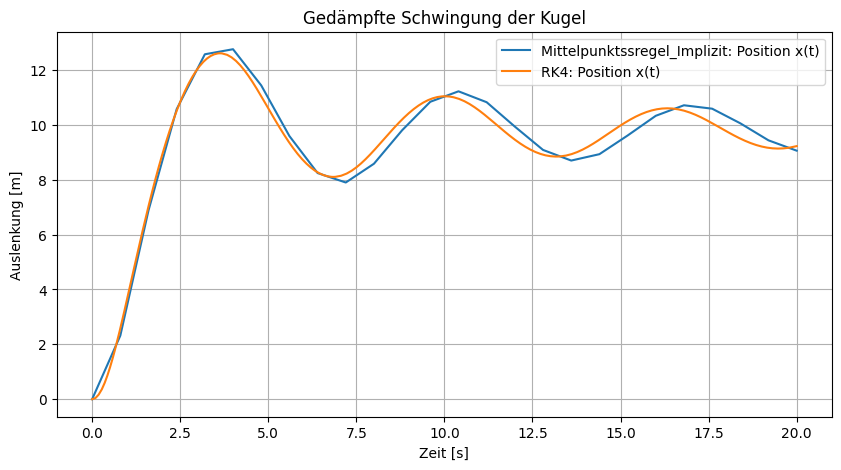

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(t_MP_I, ort_MP_I, label="Mittelpunktssregel_Implizit: Position x(t)")
plt.plot(t_RK4, ort_RK4, label="RK4: Position x(t)")
plt.xlabel("Zeit [s]")
plt.ylabel("Auslenkung [m]")
plt.title("Gedämpfte Schwingung der Kugel")
plt.grid(True)
plt.legend()
plt.show()

# Energie untersuchen

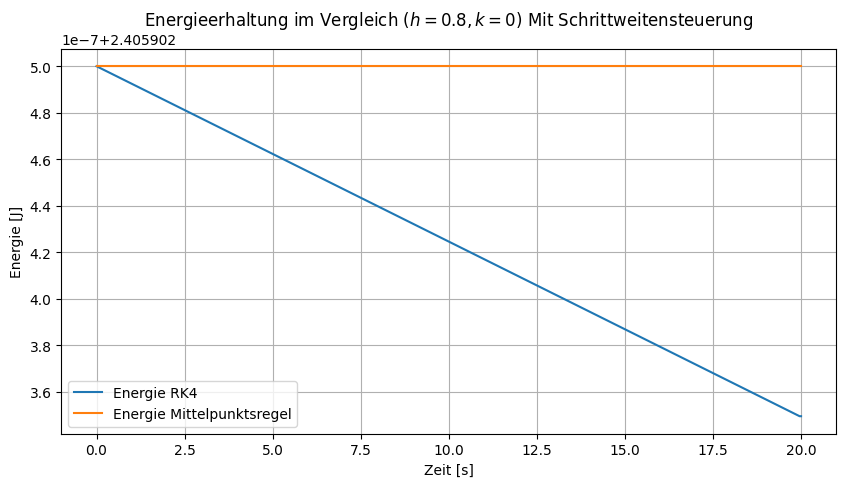

In [128]:
# aus aufgabenstellung einige sachen null setzen
k = 0
v0 = 0
h = 0.8

def berechne_energie(y_ergebnisse, ks, m, g):
    #Spalte 0 = Ort, Spalte 1 = Geschwindigkeit.
    x = y_ergebnisse[:, 0]
    v = y_ergebnisse[:, 1]
    # Aus auufgabenstellung
    E = 0.5 * ks * (x - (m * g / ks))**2 + 0.5 * m * v**2
    return E


# Spalte 0: Ort x(t)
# Spalte 1: Geschwindigkeit v(t)
t_MP_I, MP_I_y_ergebnisse = Mittelpunktsregel_Impl_Systems(FederSystem, Jaccobi_FederSystem, t_start, y0, t_end, h)
ort_MP_I = MP_I_y_ergebnisse[:, 0]
geschwindigkeit = MP_I_y_ergebnisse[:, 1]


t_RK4, RK4_y_ergebnisse = RK4_Schrittweitensteuerung_Systems(FederSystem, t_start, y0, t_end, tol=1e-5)
ort_RK4 = RK4_y_ergebnisse[:, 0]
geschwindigkeit = RK4_y_ergebnisse[:, 1]


#mit ergebnissen der funktionen von oben
E_rk = berechne_energie(RK4_y_ergebnisse, ks, m, g)
E_mp = berechne_energie(MP_I_y_ergebnisse, ks, m, g)

plt.figure(figsize=(10, 5))
plt.plot(t_RK4, E_rk, label="Energie RK4")
plt.plot(t_MP_I, E_mp, label="Energie Mittelpunktsregel")
plt.title("Energieerhaltung im Vergleich ($h=0.8, k=0$) Mit Schrittweitensteuerung")
plt.ylabel("Energie [J]")
plt.xlabel("Zeit [s]")
plt.legend()
plt.grid(True)
plt.show()

Phasenebene?

ChatGPT:


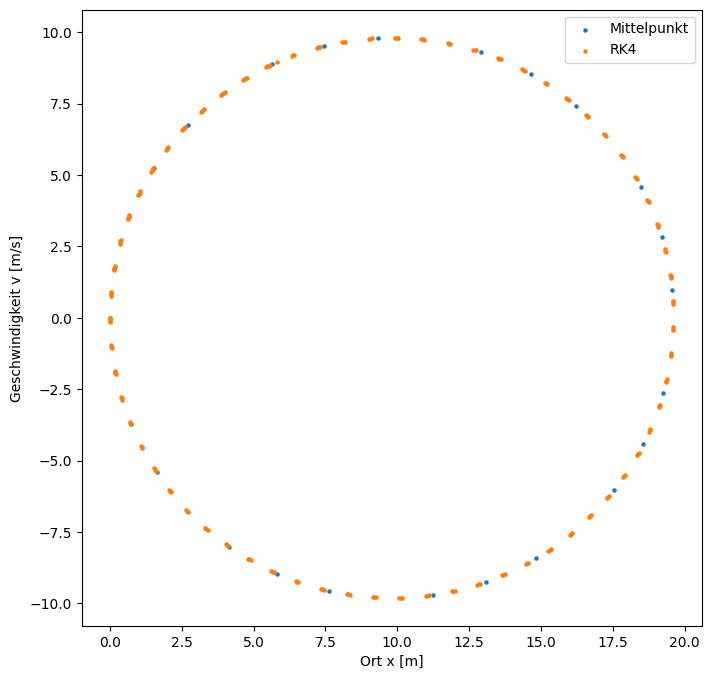

In [129]:
plt.figure(figsize=(8,8))
plt.scatter(MP_I_y_ergebnisse[:, 0], MP_I_y_ergebnisse[:, 1], label="Mittelpunkt", s=5)
plt.scatter(RK4_y_ergebnisse[:, 0], RK4_y_ergebnisse[:, 1], label="RK4", s=5)
plt.xlabel("Ort x [m]")
plt.ylabel("Geschwindigkeit v [m/s]")
plt.legend()
plt.show()